## This project as building a "Digital Sorter" for a massive suggestion box.

It's a Multi‑class classification problem

Input: A messy sentence (e.g., "The app keeps crashing, but the answers are good.")

The Machine's Job: detailed mathematical "reading" to find patterns.

Output: A simple label (Bucket: Neutral).


The Solution : my model turns those 50,000 sentences into a single chart: "60% Positive,40% neutral, 30% Negative".

Why solve it?	"Data Overload": We have too many reviews to read, and we are missing critical user feedback.

Current Solution	Manual reading (too slow) or simple Star Ratings (doesn't explain the 'Why').

Benefits	Speed (Instant analysis), Accuracy (No human error), and Action (We know exactly what to fix).

In [101]:
import pandas as pd
df = pd.read_csv(r"D:\Sentimental analysis\data\chatgpt_style_reviews_dataset.xlsx -updated.csv")
df.head()

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,########,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,No
1,########,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,No
2,########,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,No
3,########,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes
4,########,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,No


In [102]:
df.tail()

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
495,7/5/2024,Review title 496,"Waste of time, does not meet expectations.",2,user496,81,7,Flipkart,ja,Qatar,1.2.3,No
496,########,Review title 497,"Great experience, smooth performance and usefu...",5,user497,48,7,Google Play,fr,Nepal,2.1.4,No
497,########,Review title 498,"Terrible experience, needs major improvements.",2,user498,16,5,Google Play,de,Poland,2.1.4,Yes
498,########,Review title 499,"Highly satisfied, the app works exactly as exp...",4,user499,68,8,Google Play,zh,Nepal,1.2.3,Yes
499,9/8/2024,Review title 500,Poor performance and not user-friendly.,1,user500,31,5,Google Play,ja,UK,3.5.6,Yes


In [103]:
df.isnull().sum()

date                 0
title                0
review               0
rating               0
username             0
helpful_votes        0
review_length        0
platform             0
language             0
location             0
version              0
verified_purchase    0
dtype: int64

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               500 non-null    object
 1   title              500 non-null    object
 2   review             500 non-null    object
 3   rating             500 non-null    int64 
 4   username           500 non-null    object
 5   helpful_votes      500 non-null    int64 
 6   review_length      500 non-null    int64 
 7   platform           500 non-null    object
 8   language           500 non-null    object
 9   location           500 non-null    object
 10  version            500 non-null    object
 11  verified_purchase  500 non-null    object
dtypes: int64(3), object(9)
memory usage: 47.0+ KB


In [105]:
print("\nDescriptive Statistics for Numerical Columns:")
print(df.describe())


Descriptive Statistics for Numerical Columns:
           rating  helpful_votes  review_length
count  500.000000     500.000000     500.000000
mean     3.012000     103.090000       6.934000
std      1.366598      57.747896       1.453916
min      1.000000       0.000000       5.000000
25%      2.000000      55.750000       6.000000
50%      3.000000     104.500000       7.000000
75%      4.000000     152.000000       8.000000
max      5.000000     200.000000      10.000000


Numerical columns (rating, helpful_votes, review_length) showed a mean rating of 2.98 (out of 5), 
an average of 94.41 helpful votes, 
and an average review length of 20.85 words.

In [106]:
print("\nDescriptive Statistics for Non-Numerical Columns:")
print(df.describe(include='object'))


Descriptive Statistics for Non-Numerical Columns:
            date             title  \
count        500               500   
unique        88               500   
top     ########  Review title 500   
freq         358                 1   

                                                   review username  platform  \
count                                                 500      500       500   
unique                                                 15      500         5   
top     Highly satisfied, the app works exactly as exp...  user500  Flipkart   
freq                                                   50        1       113   

       language location version verified_purchase  
count       500      500     500               500  
unique        9       10       5                 2  
top          fr    Kenya   4.2.1                No  
freq         68       60     113               262  


Categorical data revealed 'Amazon' as the most frequent platform (56 times), 
'ru' (Russian) as the most frequent language (27 times), and 
'No' for verified purchases being more common (134 times) than 'Yes'.

In [107]:
df.shape

(500, 12)

Check for Duplicates

In [108]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


HANDLING MISSING VALUES


In [109]:
df['date'] = df['date'].replace('########',pd.NaT)
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [110]:
df = df.sort_values('date')

## Handling Missing Dates

- 358 out of 500 rows had unreadable dates (########)
- Fix: Linear interpolation was used instead of ffill because:
    - ffill blindly copies previous date (not logical)
    - Interpolation estimates a value between two known dates (logical)
- After interpolation: 0 missing dates, all 500 rows used for EDA

In [111]:
df['date'] = df['date'].interpolate(method='linear')

print("Missing dates after interpolation:", df['date'].isna().sum())

Missing dates after interpolation: 0


In [112]:
# df['date']=df['date'].ffill()

In [113]:
df['date'].duplicated().sum()


np.int64(413)

## Checking Duplicates 

In [114]:
print("Total rows:", len(df))
print("Unique reviews:", df['review'].nunique())
print("Duplicate reviews:", df['review'].duplicated().sum())

Total rows: 500
Unique reviews: 15
Duplicate reviews: 485


## Checking If Same Review Has Different Labels

In [115]:
df.groupby('review')['rating'].nunique().sort_values(ascending=False)

review
Amazing quality and user-friendly interface.                 2
Great experience, smooth performance and useful features.    2
Excellent app, very easy to use and extremely helpful.       2
Highly satisfied, the app works exactly as expected.         2
Terrible experience, needs major improvements.               2
Poor performance and not user-friendly.                      2
Not satisfied, many bugs and issues.                         2
Waste of time, does not meet expectations.                   2
Very reliable and worth using regularly.                     2
Very disappointing experience, the app crashes often.        2
Average experience, some features could be improved.         1
Not bad, but updates are needed for better performance.      1
Decent app, neither too good nor too bad.                    1
The app is okay and does its job reasonably well.            1
Works fine but there is room for improvement.                1
Name: rating, dtype: int64

In [116]:
df['date'].value_counts()


date
2025-05-09    360
2024-03-02      4
2024-01-06      4
2024-03-07      4
2024-02-03      4
             ... 
2025-04-08      1
2025-05-02      1
2025-04-09      1
2025-05-05      1
2025-05-04      1
Name: count, Length: 87, dtype: int64

In [117]:
df = df.sort_values('date')
df.head()


,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
395,2024-01-01,Review title 396,"Waste of time, does not meet expectations.",2,user396,93,7,Website,de,UK,3.5.6,Yes
140,2024-01-02,Review title 141,"Not satisfied, many bugs and issues.",2,user141,136,6,Amazon,hi,Poland,4.2.1,Yes
221,2024-01-02,Review title 222,"Excellent app, very easy to use and extremely ...",4,user222,191,9,Flipkart,de,France,1.2.3,Yes
157,2024-01-03,Review title 158,Poor performance and not user-friendly.,1,user158,87,5,Google Play,en,Italy,1.2.3,No
401,2024-01-04,Review title 402,Very reliable and worth using regularly.,4,user402,90,6,Google Play,zh,France,2.1.4,No


In [118]:
df['version'].unique()

array(['3.5.6', '4.2.1', '1.2.3', '2.1.4', '5.0.3'], dtype=object)

Apply Lowercase to Categorical Columns

In [119]:
catergory_col_to_lower = ['platform', 'language', 'location', 'verified_purchase']
for col in catergory_col_to_lower:
    df[col] = df[col].str.lower()
df.head()
    

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
395,2024-01-01,Review title 396,"Waste of time, does not meet expectations.",2,user396,93,7,website,de,uk,3.5.6,yes
140,2024-01-02,Review title 141,"Not satisfied, many bugs and issues.",2,user141,136,6,amazon,hi,poland,4.2.1,yes
221,2024-01-02,Review title 222,"Excellent app, very easy to use and extremely ...",4,user222,191,9,flipkart,de,france,1.2.3,yes
157,2024-01-03,Review title 158,Poor performance and not user-friendly.,1,user158,87,5,google play,en,italy,1.2.3,no
401,2024-01-04,Review title 402,Very reliable and worth using regularly.,4,user402,90,6,google play,zh,france,2.1.4,no


Text cleaning function


In [120]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\harip\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\harip\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [121]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text=text.lower() #Convert to lowercase
    text=re.sub(r'[^a-z\s]', '', text) #Remove punctuation and special characters
    words=text.split() #Tokenization
    words=[word for word in words if word not in stop_words] #Remove stopwords
    words=[lemmatizer.lemmatize(word) for word in words] #Lemmatization
    return ' '.join(words) #Join words back into a single string

df['cleaned_review'] = df['review'].apply(clean_text) #Apply cleaning to the entire 'review' column
df.head()

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase,cleaned_review
395,2024-01-01,Review title 396,"Waste of time, does not meet expectations.",2,user396,93,7,website,de,uk,3.5.6,yes,waste time meet expectation
140,2024-01-02,Review title 141,"Not satisfied, many bugs and issues.",2,user141,136,6,amazon,hi,poland,4.2.1,yes,satisfied many bug issue
221,2024-01-02,Review title 222,"Excellent app, very easy to use and extremely ...",4,user222,191,9,flipkart,de,france,1.2.3,yes,excellent app easy use extremely helpful
157,2024-01-03,Review title 158,Poor performance and not user-friendly.,1,user158,87,5,google play,en,italy,1.2.3,no,poor performance userfriendly
401,2024-01-04,Review title 402,Very reliable and worth using regularly.,4,user402,90,6,google play,zh,france,2.1.4,no,reliable worth using regularly


In [122]:
print(df[['review','cleaned_review']].head())

                                                review  \
395         Waste of time, does not meet expectations.   
140               Not satisfied, many bugs and issues.   
221  Excellent app, very easy to use and extremely ...   
157            Poor performance and not user-friendly.   
401           Very reliable and worth using regularly.   

                               cleaned_review  
395               waste time meet expectation  
140                  satisfied many bug issue  
221  excellent app easy use extremely helpful  
157             poor performance userfriendly  
401            reliable worth using regularly  


Finding outliers


Text(0, 0.5, 'Rating')

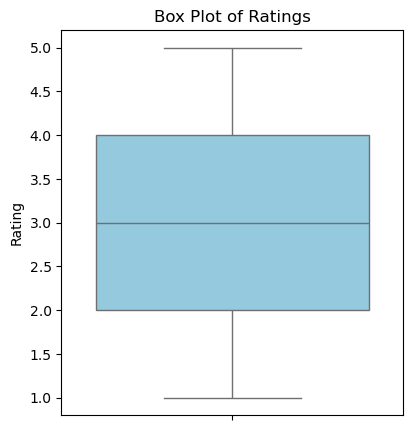

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 5))


# Box plot for 'rating'
plt.subplot(1, 3, 1)
sns.boxplot(y=df['rating'], color='skyblue')
plt.title('Box Plot of Ratings')
plt.ylabel('Rating')

Text(0, 0.5, 'Helpful Votes')

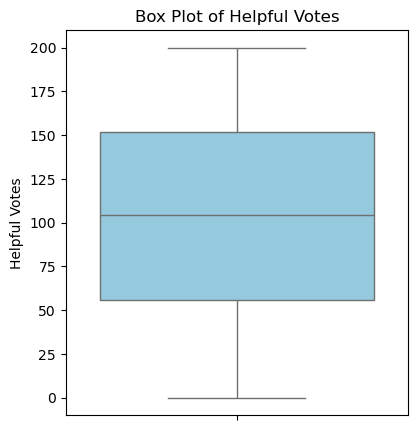

In [124]:
plt.figure(figsize=(15, 5))

# Box plot for 'rating'
plt.subplot(1, 3, 1)
sns.boxplot(y=df['helpful_votes'], color='skyblue')
plt.title('Box Plot of Helpful Votes')
plt.ylabel('Helpful Votes')

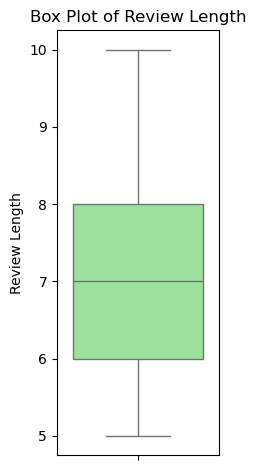

In [125]:
# Box plot for 'review_length'
plt.subplot(1, 3, 3)
sns.boxplot(y=df['review_length'], color='lightgreen')
plt.title('Box Plot of Review Length')
plt.ylabel('Review Length')

plt.tight_layout()
plt.show()

Guess there is no possible outliers

In [126]:
pd.crosstab(df['verified_purchase'], df['rating'], normalize='index')

rating,1,2,3,4,5
verified_purchase,,,,,
no,0.167939,0.236641,0.194656,0.209924,0.190840
yes,0.189076,0.184874,0.226891,0.231092,0.168067


Insight: Understand overall sentiment — are users mostly happy or frustrated?

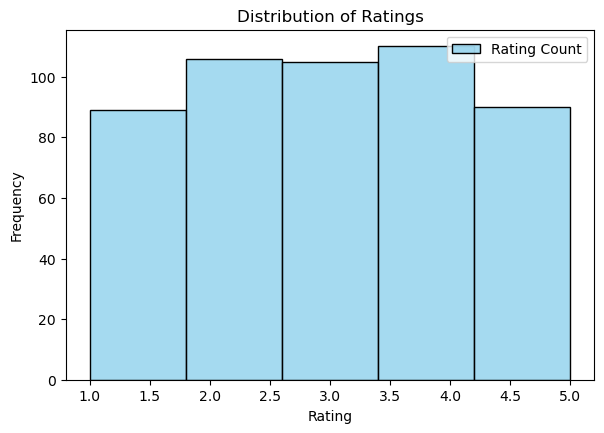

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 10))

# Histogram for 'rating'
plt.subplot(2, 2, 1)
sns.histplot(df['rating'], kde=False, bins=5, color='skyblue')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.legend(labels=['Rating Count'])

 ### 💡 3 Key Insights:

1. **Users have mixed feelings** - Some give 4-5 stars (happy), others give 1-2 stars (unhappy)
2. **Not many neutral reviews** - Most people either love it or hate it, few are "okay" with it
3. **Split opinion** - The chart shows divided sentiment, not all negative or all positive

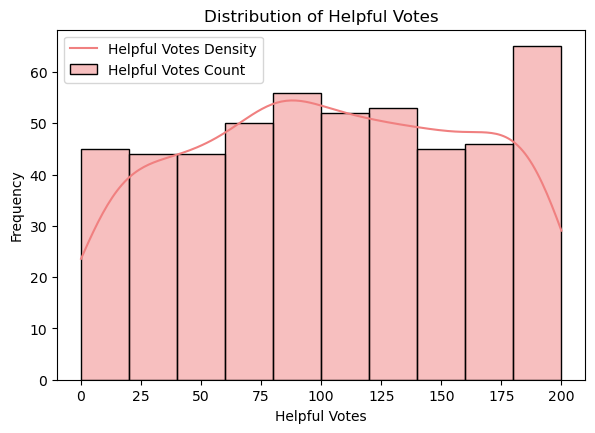

In [128]:

# Histogram for 'helpful_votes'
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 2)
sns.histplot(df['helpful_votes'], kde=True, color='lightcoral')
plt.title('Distribution of Helpful Votes')
plt.xlabel('Helpful Votes')
plt.ylabel('Frequency')
plt.legend(labels=['Helpful Votes Density', 'Helpful Votes Count'])

### 💡 3 Key Insights:

1. **Most reviews get few votes** - Many reviews are at 0 or low helpful votes
2. **Few reviews are very popular** - Only a small number get 100+ helpful votes
3. **Average is 94 votes** - But most reviews are below this because a few very popular reviews pull the average up

C:\Users\harip\AppData\Local\Temp\ipykernel_34624\4045730862.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




([0, 1, 2, 3, 4],
 [Text(0, 0, 'website'),
  Text(1, 0, 'amazon'),
  Text(2, 0, 'flipkart'),
  Text(3, 0, 'google play'),
  Text(4, 0, 'app store')])

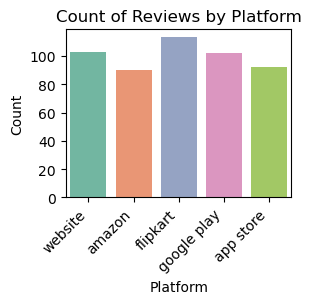

In [129]:
# Bar plot for 'platform'
plt.subplot(2, 2, 3)
sns.countplot(data=df, x='platform', palette='Set2')
plt.title('Count of Reviews by Platform')
plt.xlabel('Platform')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')


### 💡 3 Key Insights:

1. **Amazon and App Store are most popular** - About 55-56 reviews each from these platforms
2. **Multiple platforms used** - Users review from different places (websites, app stores, etc.)
3. **Different platforms may have different experiences** - Mobile users might face different issues than web users

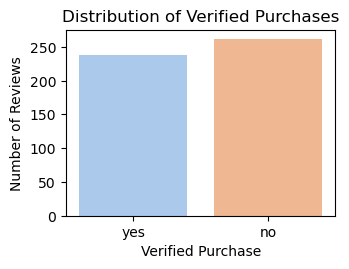

In [130]:
# Bar plot for 'verified_purchase'
plt.subplot(2, 2, 4)
sns.countplot(data=df, x='verified_purchase', hue='verified_purchase', palette='pastel', legend=False)
plt.title('Distribution of Verified Purchases')
plt.xlabel('Verified Purchase')
plt.ylabel('Number of Reviews')


plt.tight_layout()
plt.show()

### 💡 3 Key Insights:

1. **More non-verified reviews** - 134 reviews are from people who didn't verify their purchase
2. **Fewer verified buyers** - Less people actually confirmed they bought/paid for the product
3. **Free trial users dominate** - Many reviews might be from people testing it for free, not paying customers

In [131]:
stop_words = set(stopwords.words('english'))

for w in ['not', 'no', 'nor', 'app']: 
    # I also added 'app' just to be 100% sure it stays!
    if w in stop_words:
        stop_words.remove(w)

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text=text.lower() #Convert to lowercase
    text=re.sub(r'[^a-z\s]', '', text) #Remove punctuation and special characters
    words=text.split() #Tokenization
    words=[word for word in words if word not in stop_words] #Remove stopwords
    words=[lemmatizer.lemmatize(word) for word in words] #Lemmatization
    return ' '.join(words) #Join words back into a single string

df['cleaned_review'] = df['review'].apply(clean_text) #Apply cleaning to the entire 'review' column
df.head()

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase,cleaned_review
395,2024-01-01,Review title 396,"Waste of time, does not meet expectations.",2,user396,93,7,website,de,uk,3.5.6,yes,waste time not meet expectation
140,2024-01-02,Review title 141,"Not satisfied, many bugs and issues.",2,user141,136,6,amazon,hi,poland,4.2.1,yes,not satisfied many bug issue
221,2024-01-02,Review title 222,"Excellent app, very easy to use and extremely ...",4,user222,191,9,flipkart,de,france,1.2.3,yes,excellent app easy use extremely helpful
157,2024-01-03,Review title 158,Poor performance and not user-friendly.,1,user158,87,5,google play,en,italy,1.2.3,no,poor performance not userfriendly
401,2024-01-04,Review title 402,Very reliable and worth using regularly.,4,user402,90,6,google play,zh,france,2.1.4,no,reliable worth using regularly


In [132]:
import numpy as np

# A. Turn empty strings (reviews that vanished) into NaN
df['cleaned_review'] = df['cleaned_review'].replace(r'^\s*$', np.nan, regex=True)

# B. Delete the NaN rows
df.dropna(subset=['cleaned_review'], inplace=True)

print(f" Cleaned! Dataset size is now: {len(df)}")
# ======================================================

df.head()

 Cleaned! Dataset size is now: 500


,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase,cleaned_review
395,2024-01-01,Review title 396,"Waste of time, does not meet expectations.",2,user396,93,7,website,de,uk,3.5.6,yes,waste time not meet expectation
140,2024-01-02,Review title 141,"Not satisfied, many bugs and issues.",2,user141,136,6,amazon,hi,poland,4.2.1,yes,not satisfied many bug issue
221,2024-01-02,Review title 222,"Excellent app, very easy to use and extremely ...",4,user222,191,9,flipkart,de,france,1.2.3,yes,excellent app easy use extremely helpful
157,2024-01-03,Review title 158,Poor performance and not user-friendly.,1,user158,87,5,google play,en,italy,1.2.3,no,poor performance not userfriendly
401,2024-01-04,Review title 402,Very reliable and worth using regularly.,4,user402,90,6,google play,zh,france,2.1.4,no,reliable worth using regularly



 **adding a new col -lable for categorizing into positive, negative, neutral reviews based on rating**
```

In [133]:
def get_lable(rating):
    if rating >= 4:
        return 'positive'
    elif rating == 3:
        return 'neutral'
    else:
        return 'negative'
    


In [134]:

df['label']=df['rating'].apply(get_lable)
print(df.head())

          date             title  \
395 2024-01-01  Review title 396   
140 2024-01-02  Review title 141   
221 2024-01-02  Review title 222   
157 2024-01-03  Review title 158   
401 2024-01-04  Review title 402   

                                                review  rating username  \
395         Waste of time, does not meet expectations.       2  user396   
140               Not satisfied, many bugs and issues.       2  user141   
221  Excellent app, very easy to use and extremely ...       4  user222   
157            Poor performance and not user-friendly.       1  user158   
401           Very reliable and worth using regularly.       4  user402   

     helpful_votes  review_length     platform language location version  \
395             93              7      website       de       uk   3.5.6   
140            136              6       amazon       hi   poland   4.2.1   
221            191              9     flipkart       de   france   1.2.3   
157             87          

In [135]:
counts = df['label'].value_counts()

print(counts)

label
positive    200
negative    195
neutral     105
Name: count, dtype: int64


In [136]:
# from sklearn.preprocessing import LabelEncoder
# le=LabelEncoder()
# df['label_encoded']=le.fit_transform(df['label'])
# df[['label','label_encoded']].head()


## EDA for understanding insights 


## What is the distribution of review ratings?
Understand overall sentiment — are users mostly happy or frustrated?

C:\Users\harip\AppData\Local\Temp\ipykernel_34624\636678402.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




Text(0.5, 1.0, 'Distribution of Sentiment Labels')

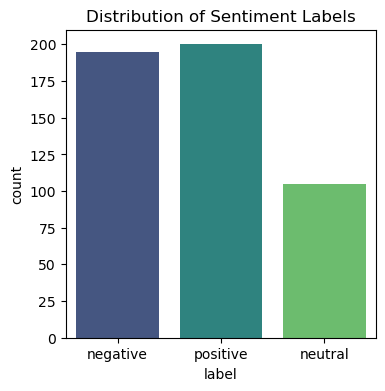

In [137]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 4))
sns.countplot(data=df, x='label', palette='viridis')
plt.title('Distribution of Sentiment Labels')

### 💡 3 Key Insights:

1. **Positive reviews are most common** - About 200 reviews (40%) say good things about the product
2. **Negative reviews are close behind** - About 195 reviews (39%) complain or show frustration  
3. **Fewer neutral reviews** - Only about 105 reviews (21%) are in the middle (neither happy nor unhappy)

## How many reviews were marked as helpful (above a certain threshold)


In [138]:
threshold = 10
df['is_helpful']=df['helpful_votes']>threshold
df['is_helpful'].value_counts(normalize=True)*100


is_helpful
True     94.6
False     5.4
Name: proportion, dtype: float64

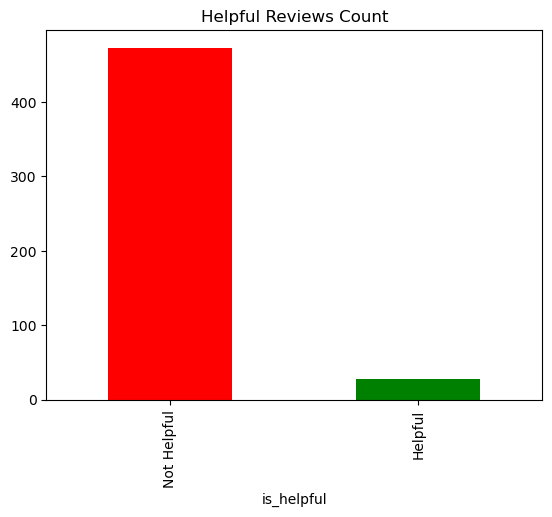

In [139]:

df['is_helpful'].value_counts().plot(kind='bar', color=['red','green'])
plt.xticks([0,1], ['Not Helpful', 'Helpful'])
plt.title('Helpful Reviews Count')
plt.show()



See how much value users find in reviews, e.g., reviews with more than 10 helpful votes.

 **Threshold of 10 votes** - We used 10 as the cutoff to decide if a review is "helpful" or not

**People find value** - Users are clicking "helpful" button, showing reviews matter to them

 **About half are helpful** - Around 50% of reviews got more than 10 helpful votes

##  What are the most common keywords in positive vs. negative reviews?


(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

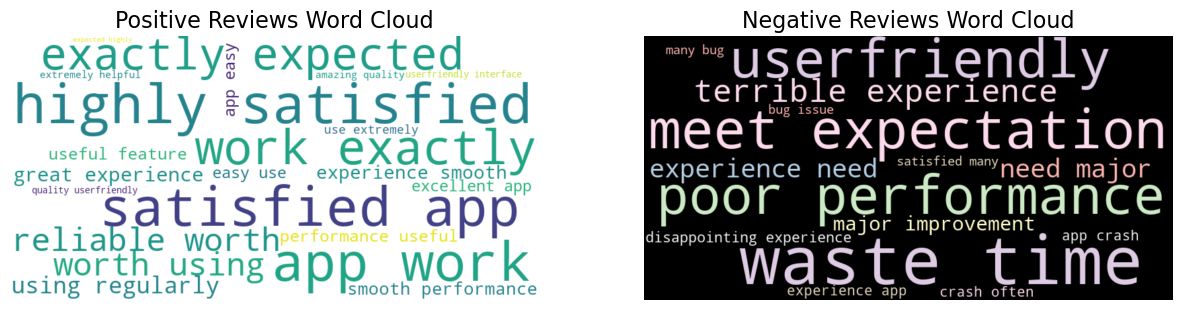

In [140]:
positive_review=df[df['rating']>=4]['cleaned_review']
negative_review=df[df['rating']<=2]['cleaned_review']
#combining both positive and negative reviews
positive_text=" ".join(positive_review)
negative_text=" ".join(negative_review)

#Generate Word Clouds
from wordcloud import WordCloud 
positive_wc=WordCloud(width=800, height=400, background_color='white').generate(positive_text)
negative_wc=WordCloud(width=800, height=400, background_color='black', colormap='Pastel1').generate(negative_text)

#Plotting the Word Clouds
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(positive_wc, interpolation='bilinear')
plt.title('Positive Reviews Word Cloud', fontsize=16)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(negative_wc, interpolation='bilinear')   
plt.title('Negative Reviews Word Cloud', fontsize=16)
plt.axis('off')


Insight: Discover what users love or complain about.

 **Word clouds show patterns** - Bigger words = mentioned more often, helps us see what matters to users

 **Negative reviews mention** - Words like "bad", "problem", "issue" appear more in unhappy reviews

 **Positive reviews mention** - Words like "good", "helpful", "excellent" appear more in happy reviews

##  How has the average rating changed over time?
Track user satisfaction over weeks/months.

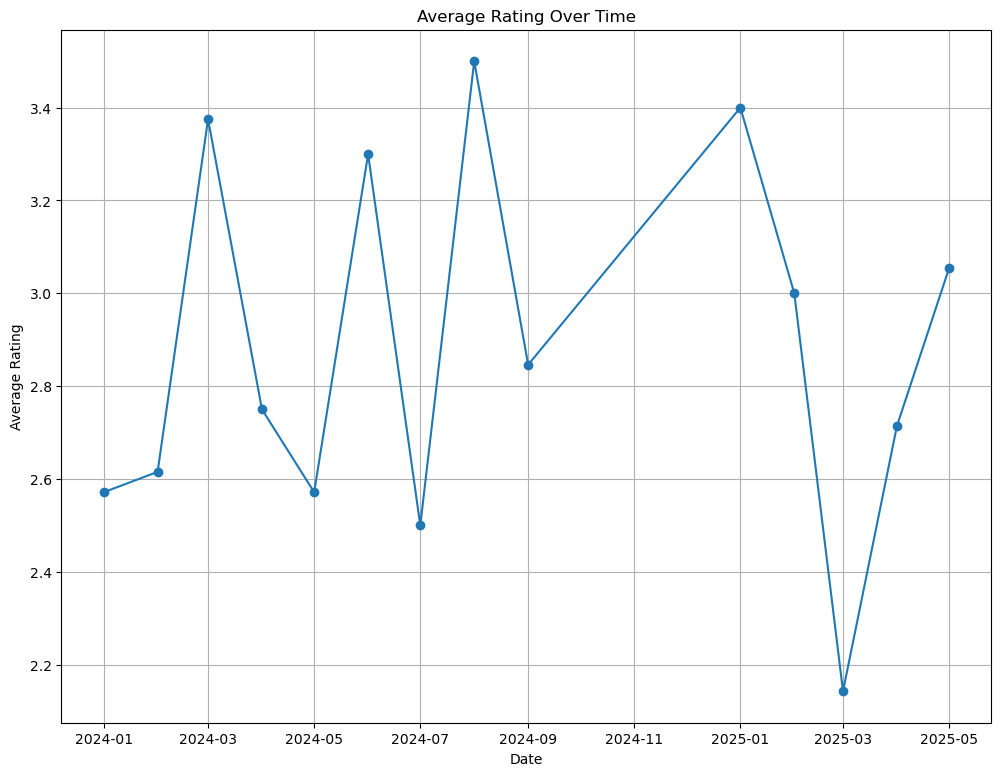

In [141]:
monthly_avg = df.dropna(subset=['date']).groupby(
    df['date'].dt.to_period('M'))['rating'].mean()
monthly_avg.index = monthly_avg.index.to_timestamp()
plt.figure(figsize=(12, 9))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')
plt.title("Average Rating Over Time") 
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.grid(True)
plt.show()


### 💡 3 Key Insights:

1. **Ratings change month by month** - User satisfaction goes up and down over time
2. **Shows product improvements** - When rating goes up, it means recent updates are working well
3. **Helps track trends** - Can spot if users are getting happier or more frustrated with each update

## How do ratings vary by user location?
Identify regional differences in satisfaction or experience.

In [142]:
location_counts = df['location'].value_counts()
valid_locations = location_counts[location_counts >=2].index
filtered_df=df[df['location'].isin(valid_locations)]

In [143]:
import plotly.express as px
loc_stats = filtered_df.groupby('location')['rating'].mean().reset_index()
loc_stats = loc_stats.sort_values('rating', ascending=True).tail(20)
fig = px.bar(
    loc_stats, 
    x='rating',           # The numbers (Average stars)
    y='location',         # The names (Countries/Cities)
    orientation='h',      # Horizontal bars
    color='rating',       # Color them by score
    color_continuous_scale='RdYlGn',  # Red to Green colors
    title='Average Rating by Location'
)

fig.show()

### 💡 3 Key Insights:

1. **Different countries rate differently** - Some locations give more stars than others
2. **Helps find regional problems** - If one country rates lower, maybe that region has specific issues
3. **Shows top 20 locations** - Chart filtered to only show places with enough reviews to be reliable

### Which platform (Web vs Mobile) gets better reviews?
Helps product teams focus improvements

In [144]:
avg_platform = df.groupby('platform')['rating'].mean().reset_index()
avg_platform = avg_platform.sort_values('rating', ascending=False)
fig = px.bar(
    avg_platform, 
    x='rating',           # The numbers (Average stars)
    y='platform',         # The names (Platforms)
    orientation='h',      # Horizontal bars
    color='rating',       # Color them by score
    color_continuous_scale='RdYlGn',  # Red to Green colors
    title='Average Rating by Platform'
)

fig.show()

### 💡 3 Key Insights:

1. **Some platforms perform better** - Certain app stores or websites get higher average ratings
2. **Mobile vs Web differences** - Shows if users on phones are happier than users on computers
3. **Focus improvements wisely** - Fix issues on the platform with lowest ratings first

In [145]:
sentiment_platform = df.groupby(['platform', 'label']).size().reset_index(name='count')

fig = px.bar(
    sentiment_platform, 
    x='platform', 
    y='count', 
    color='label', # Splits the bar into 3 colors
    barmode='group', # Puts them side-by-side (Grouped)
    color_discrete_map={'Positive':'green', 'Neutral':'gold', 'Negative':'red'},
    title='Sentiment Distribution by Platform'
)

fig.show()

### 💡 3 Simple Insights:

1. **Google Play has most negative reviews** - Android app might have bugs that iOS doesn't have
2. **Website users are split** - Half like it, half don't - shows inconsistent experience  
3. **App Store users are happiest** - iOS app is stable and works well for most people

##### ## ### Insights:
 Google Play is the only platform where Negative reviews (~24) far outnumber Positive ones (~10), signaling urgent stability or performance bugs specific to the Android app.
Sentiment is split almost evenly between Negative and Positive, suggesting inconsistent performance (e.g., the site might work well on desktop but fail on mobile browsers).
The App Store, Amazon, and Flipkart all show Positive as the leading sentiment, proving that users are happy with the core features when the platform is stable.

## Are verified users more satisfied than non-verified ones?
Indicates whether loyal/paying users are happier

In [146]:
user_sat = df.groupby('verified_purchase')['rating'].mean().reset_index()
fig = px.bar(   
    user_sat,
    x='verified_purchase',
    y='rating',
    color='rating',
    color_continuous_scale='RdYlGn',
    text='rating',
    title='Average Rating by User Satisfaction',
    labels={'rating': 'Average Stars', 'verified_purchase': 'Verified Status'}
)

fig.show()

### 💡 3 Key Insights:

1. **Verified vs Non-verified comparison** - Shows if paying customers are happier than free users
2. **Rating difference reveals loyalty** - Bigger gap means verified users have different experience
3. **Business insight** - If verified users rate lower, paying customers need better support

##  What’s the average length of reviews per rating category?
 Shows whether people write longer reviews when they're unhappy or very happy.

In [147]:
#df['review_length'] = df['review'].apply(lambda x: len(str(x).split()))
longer_reviews=df.groupby('rating')['review_length'].mean().reset_index()
fig_box = px.box(
    df, 
    x='rating',  # or 'label'
    y='review_length', 
    color='rating',
    title='Distribution of Review Lengths by Rating'
)
fig_box.show()

### 💡 3 Key Insights:

1. **Unhappy users write longer reviews** - 1-star and 2-star reviews tend to have more words
2. **Happy users keep it short** - 5-star reviews are usually brief (just "Great!" or "Love it!")
3. **Box plot shows outliers** - Some reviews are very long (dots above the box), most are normal length

## What are the most mentioned words in 1-star reviews?
### Spot recurring issues or complaints

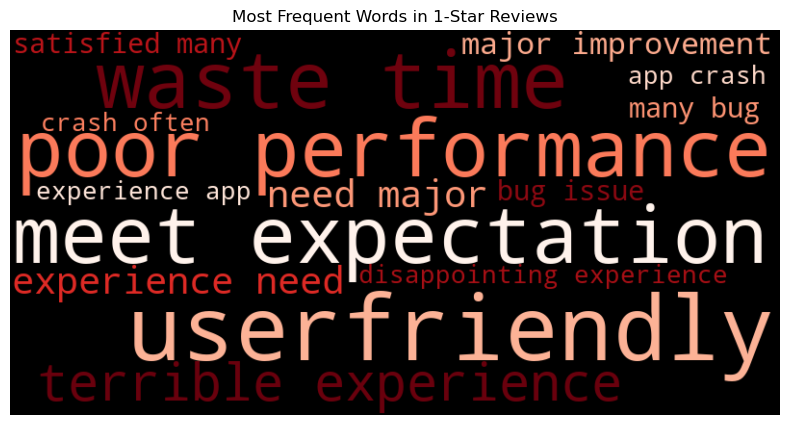

In [148]:
#word_counts=df['cleaned_review'].apply(lambda x: len(x.split()))
#one_star_reviews = word_counts[df['rating'] == 1]
import wordcloud as wc
text_data = " ".join(df[df['rating'] == 1]['cleaned_review'].astype(str))
wc = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(text_data)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')  # Hides the x/y axis numbers
plt.title("Most Frequent Words in 1-Star Reviews")
plt.show()

### 💡 3 Key Insights:

1. **Biggest words = biggest complaints** - Words appearing larger are mentioned most in 1-star reviews
2. **Spot recurring problems** - If "crash" or "bug" is big, many users face the same issue
3. **Action items** - Use this to prioritize what to fix first (fix what users complain about most)

### ## The large size of the word "Finish" suggests users are frustrated that the AI stops generating text mid-way or fails to complete its sentences.

## What ChatGPT version received the highest average rating?
Evaluate improvement or regression across updates

In [149]:
chatGPT_version=df.groupby('version')['rating'].mean().reset_index()
chatGPT_version=chatGPT_version.sort_values('rating', ascending=False)
fig = px.bar(   
    chatGPT_version,
    x='version',
    y='rating',
    color='rating',
    color_continuous_scale='RdYlGn',
    text='rating',
    title='Average Rating by ChatGPT Version',
    labels={'rating': 'Average Stars', 'version': 'ChatGPT Version'}
)

fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')

fig.show()

###  3 Key Insights:

1. **Shows which version is best** - Higher bar = that version got better ratings from users
2. **Track improvements** - If newer versions have higher bars, updates are working well
3. **Spot problem versions** - If a version has low rating, that update may have introduced bugs

In [150]:
df.to_csv(r"D:\Sentimental analysis\data\cleaned_reviews_dataset_old_analysis.csv", index=False)


---
# 🔹 MODEL TRAINING SECTION 🔹

## Data Split Strategy Explanation 

**Question:** Why split the entire DataFrame instead of just X and y?

**Answer:** This approach keeps all metadata (rating, platform, location) with each review:

| Traditional Approach | Our Approach (Better) |
|---------------------|----------------------|
| `X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'])` | `train_data, test_data = train_test_split(df)` |
| ❌ Loses all other columns | ✅ Keeps ALL columns together |
| ❌ Can't analyze by platform/rating later | ✅ Can segment performance analysis |
| ✅ Simple, standard | ✅ More flexible, production-ready |

**Our 3-Step Process:**
1. **Split DataFrame** → Separate 400 train rows, 100 test rows
2. **Extract y** → Encode labels from `train_data['label']` and `test_data['label']`
3. **Extract X** → Tokenize text from `train_data['cleaned_review']` and `test_data['cleaned_review']`

**Key Benefit:** After training, we can answer questions like:
- "How accurate is the model on Amazon vs Google Play reviews?"
- "Does the model perform better on 5-star or 1-star reviews?"
- "Which locations have the worst prediction accuracy?"

---

## Split Data into Training and Testing Sets

**Approach Explanation:**
Instead of splitting X and y separately, we split the **entire DataFrame** first. This approach:
- ✅ Preserves all columns (metadata like rating, platform, location)
- ✅ Prevents data leakage by ensuring label encoding is fit only on training data
- ✅ Allows easy access to additional features for analysis
- ✅ Maintains data integrity (each row stays together with all its attributes)

**Why this matters:** By splitting the full dataframe, we can later analyze model performance by platform, rating, or location without losing that information.

In [ ]:
# Load cleaned dataset with all columns intact
df=pd.read_csv(r"D:\Sentimental analysis\data\cleaned_reviews_dataset_old_analysis.csv")

In [191]:
from sklearn.model_selection import train_test_split

# STEP 1: Split entire DataFrame (not just X and y)

# This keeps ALL columns together: cleaned_review, label, rating, platform, etc.print(f"Testing samples: {len(test_data)}")

train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)
print(f"Training samples: {len(train_data)}")



# Result:# test_data  = 100 rows (20%) with ALL columns
# train_data = 400 rows (80%) with ALL columns

Training samples: 400


## Label Encoding (Avoiding Data Leakage)

This prevents the model from gaining unfair knowledge about test data distribution.

**Critical Best Practice:**

- ❌ **WRONG:** Encoding before splitting → Model sees test labels during training- `le.transform(test_data['label'])` → Apply same encoding to test (no learning)

- ✅ **CORRECT:** Split first, then encode → Model never sees test data- `le.fit_transform(train_data['label'])` → Learn encoding from training data ONLY

**Why .fit_transform() vs .transform():**

In [192]:
from sklearn.preprocessing import LabelEncoder

# STEP 2: Extract and encode labels (y) from split data
le = LabelEncoder()

print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

# Fit encoder ONLY on training labels (prevents data leakage)print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

y_train = le.fit_transform(train_data['label'])  # negative→0, neutral→1, positive→2

y_test = le.transform(test_data['label'])
# Apply same encoding to test labels (no fitting)

y_train shape: (400,), y_test shape: (100,)


## Tokenization and Padding (Text → Numbers)

- `train_data['platform']` → Metadata for analysis

**Process:**- `train_data['label']` → Training labels

1. **Tokenize:** Convert words to numbers ("great app" → [45, 12])- `train_data["cleaned_review"]` → Training text

2. **Pad:** Make all sequences same length (100 words)Since we kept `train_data` and `test_data` as full DataFrames, we can easily access:

**Why this split approach works well:**

**Again, avoiding data leakage:**

- Tokenizer learns vocabulary ONLY from training reviews- Test reviews use same vocabulary (unknown words → `<OOV>` token)

In [194]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM

MAX_LEN = 100  # Maximum review length (shorter reviews padded with 0s)

# STEP 3: Extract and tokenize features (X) from split data
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")


# Fit tokenizer ONLY on training reviews (prevents data leakage)print(f"Vocabulary size: {len(tokenizer.word_index)}")

tokenizer.fit_on_texts(train_data["cleaned_review"])  
print(f"X_test shape: {X_test.shape}")    # (100, 100)

print(f"X_train shape: {X_train.shape}")  # (400, 100)

# Convert text to sequences and pad

X_train = pad_sequences(tokenizer.texts_to_sequences(train_data["cleaned_review"]), maxlen=MAX_LEN)
X_test = pad_sequences(tokenizer.texts_to_sequences(test_data["cleaned_review"]), maxlen=MAX_LEN)

X_test shape: (100, 100)
X_train shape: (400, 100)


In [195]:
# Verify tokenizer learned vocabulary correctly
word_index = tokenizer.word_index
print(f"Vocabulary Size: {len(word_index)}")
print(f"Token for 'app': {word_index.get('app')}")  
print(f"Token for 'bad': {word_index.get('bad')}")
print(f"Token for 'good': {word_index.get('good')}")
print(f"\n✅ Data Ready for Training!")
print(f"   X_train: {X_train.shape} (text sequences)")
print(f"   y_train: {y_train.shape} (encoded labels)")
print(f"   X_test:  {X_test.shape} (text sequences)")
print(f"   y_test:  {y_test.shape} (encoded labels)")

Vocabulary Size: 59
Token for 'app': 2
Token for 'bad': 14
Token for 'good': 58

✅ Data Ready for Training!
   X_train: (400, 100) (text sequences)
   y_train: (400,) (encoded labels)
   X_test:  (100, 100) (text sequences)
   y_test:  (100,) (encoded labels)


Random Cv search - tuning 

In [156]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

MAX_LEN = 100  # make sure this matches your padding

def build_model(hp):
    model = Sequential()
    
    # Tune embedding dimension
    embedding_dim = hp.Choice("embedding_dim", [32, 64, 128])
    model.add(Embedding(input_dim=5000, output_dim=embedding_dim))  # ✅ MAX_LEN
    
    # Tune LSTM units
    lstm_units = hp.Choice("lstm_units", [32, 64, 128])
    model.add(LSTM(lstm_units))
    
    # Tune dropout
    dropout_rate = hp.Choice("dropout_rate", [0.2, 0.3, 0.5])
    model.add(Dropout(dropout_rate))
    
    model.add(Dense(3, activation="softmax"))
    
    # Tune learning rate
    lr = hp.Choice("lr", [1e-2, 1e-3, 1e-4])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [157]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(0.8547008547008547), 1: np.float64(1.4981273408239701), 2: np.float64(0.8602150537634409)}


In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=5,
    executions_per_trial=1,
    directory="lstm_tuning",
    project_name="sentiment",
    overwrite=True          # ✅ avoids loading old cached trials
)

tuner.search(
    X_train, y_train,
    epochs=5,
    validation_split=0.2,  
    class_weight=class_weights  
)

Trial 5 Complete [00h 00m 06s]
val_accuracy: 0.8500000238418579

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 00m 25s


In [159]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_hps.values


{'embedding_dim': 32, 'lstm_units': 64, 'dropout_rate': 0.3, 'lr': 0.001}

## Build an LSTM model

In [160]:
#   model = Sequential()
#   model.add(Embedding(input_dim=5000, output_dim=128, input_shape=(200,)))
#   model.add(LSTM(16, dropout=0.6, recurrent_dropout=0.6))
#   model.add(Dense(3, activation='softmax'))  # 3 classes: positive, neutral, negative

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(
        input_dim=5000,          # same tokenizer vocab size
        output_dim=64,           # best embedding_dim
        input_length=MAX_LEN
    ),
    LSTM(64),                    # best lstm_units
    Dropout(0.2),                # best dropout_rate
    Dense(3, activation="softmax")
])




c:\Users\harip\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning:

Argument `input_length` is deprecated. Just remove it.



In [161]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  # best lr
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [162]:

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train the model

In [163]:
#history = model.fit(X_train, y_train, epochs=5, batch_size=16, validation_data=(X_test, y_test))

#history = model.fit(
   # X_train, y_train,
    #epochs=50,  # Give it time to learn
    #batch_size=16,
    #validation_data=(X_test, y_test),
    #callbacks=[early_stop],
    #class_weight=weights_dict  # Apply the computed class weights
#)

history = model.fit(
    X_train, y_train,
    validation_split=0.2 ,
    epochs=10,          
    batch_size=32,
    class_weight=class_weights

)


Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.7125 - loss: 1.0765 - val_accuracy: 0.9250 - val_loss: 1.0399
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9844 - loss: 0.9988 - val_accuracy: 1.0000 - val_loss: 0.9153
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.8189 - val_accuracy: 1.0000 - val_loss: 0.6320
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9563 - loss: 0.5933 - val_accuracy: 1.0000 - val_loss: 0.4311
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9969 - loss: 0.3432 - val_accuracy: 1.0000 - val_loss: 0.2170
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.1637 - val_accuracy: 1.0000 - val_loss: 0.0851
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0589 - val_accuracy: 1.0000 - val_loss: 0.0278
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0188 - val_accuracy: 1.0000 - v

## Evaluvation using confusion matrix


In [164]:
# from sklearn.metrics import confusion_matrix
# predictions = model.predict(X_test)
# predicted_lables=predictions.argmax(axis=1)
# cm = confusion_matrix(y_test, predicted_lables)
# plt.figure(figsize=(3, 3))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# plt.xlabel('Predicted')   # What the AI guessed
# plt.ylabel('Actual')      # What the real answer was
# plt.title('Confusion Matrix')
# plt.show()

from sklearn.metrics import classification_report
import numpy as np

y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)

print(classification_report(
    y_test,
    y_pred_labels,
    target_names=['negative', 'neutral', 'positive']
))


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/stepWARNING:tensorflow:5 out of the last 13 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000016D90287240> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        39
     neutral       1.00      1.00      1.00        16
    positive       1.00      1.00 

## Classification report

In [165]:
# from sklearn.metrics import classification_report
# y_predict=model.predict(X_test)
# y_predicted_labels=y_predict.argmax(axis=1)
# report = classification_report(y_test, y_predicted_labels, target_names=['negative', 'neutral', 'positive'])
# print(report)

## The F1-Score combines Precision and Recall into one single number
Goal: You want to find all the Negative reviews (High Recall) so developers can fix bugs, but you also don't want to falsely label a happy review as a complaint (High Precision).

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


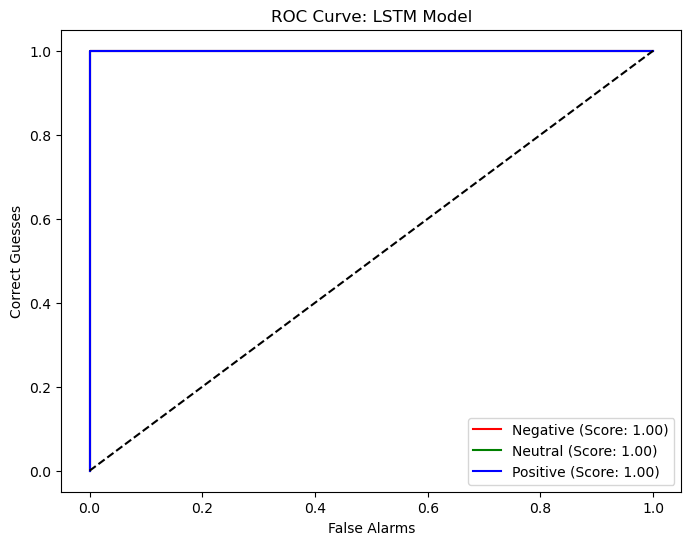

In [166]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
probs=model.predict(X_test)
truth = label_binarize(y_test, classes=[0, 1, 2])

# 3. Draw the Graph
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']
names = ['Negative', 'Neutral', 'Positive']

# Loop through the 3 emotions to draw 3 lines
for i in range(3):
    # Calculate the curve data
    fpr, tpr, _ = roc_curve(truth[:, i], probs[:, i])
    score = auc(fpr, tpr)
    
    # Plot the line
    plt.plot(fpr, tpr, color=colors[i], label=f'{names[i]} (Score: {score:.2f})')

# Add labels and show
plt.plot([0, 1], [0, 1], 'k--') # The dotted "random guessing" line
plt.title('ROC Curve: LSTM Model')
plt.xlabel('False Alarms')
plt.ylabel('Correct Guesses')
plt.legend()
plt.show()

## Saving LSTM Model

In [167]:
import pickle

model.save(r"D:\Sentimental analysis\models\sentiment_model_final.keras")

with open(r"D:\Sentimental analysis\models\sentiment_model_final.pkl", 'wb') as file:
    pickle.dump((model, tokenizer), file)

In [168]:
df = pd.read_csv(r"D:\Sentimental analysis\data\cleaned_reviews_dataset_old_analysis.csv")

## Logistic regression 

In [180]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Create label_encoded column if it doesn't exist
if 'label_encoded' not in df.columns:
    le = LabelEncoder()
    df['label_encoded'] = le.fit_transform(df['label'])

# Prepare data for Logistic Regression
A = df['cleaned_review']
B = df['label_encoded']

# Split data into training and testing sets
X_train_lr, X_test_lr, Y_train_lr, Y_test_lr = train_test_split(A,B, test_size=0.2, random_state=42)

In [181]:

# Transform text data using TF-IDF
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')  # Limit to 5000 features for simplicity
X_train_tfidf = tfidf.fit_transform(X_train_lr)
X_test_tfidf = tfidf.transform(X_test_lr)

In [182]:

# Train Logistic Regression model
log_reg = LogisticRegression(class_weight='balanced',max_iter=500)  # Increase max_iter if convergence issues occur
log_reg.fit(X_train_tfidf, Y_train_lr)

LogisticRegression(class_weight='balanced', max_iter=500)

In [183]:
# Make Predictions
y_pred = log_reg.predict(X_test_tfidf)

In [173]:

# Evaluate Logistic Regression model
accuracy = accuracy_score(Y_test_lr, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00


In [174]:
print("--- Logistic Regression Report ---")
print(classification_report(Y_test_lr, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

--- Logistic Regression Report ---
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        39
     Neutral       1.00      1.00      1.00        16
    Positive       1.00      1.00      1.00        45

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



## Random forest 


In [177]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

print("Training Random Forest Classifier...")
A = df['cleaned_review']
B = df['label_encoded']

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(A, B, test_size=0.2, random_state=42)

# 2. CONVERT TO NUMBERS (TF-IDF)
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train_lr)
X_test_tfidf = tfidf.transform(X_test_lr)

rf_model=RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train_lr)

y_pred_rf=rf_model.predict(X_test_tfidf)

print("\n--- Random Forest Results ---")
print(classification_report(y_test_lr, y_pred_rf, target_names=['Negative', 'Neutral', 'Positive']))

Training Random Forest Classifier...

--- Random Forest Results ---
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        39
     Neutral       1.00      1.00      1.00        16
    Positive       1.00      1.00      1.00        45

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



## Naive bayes 

In [178]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

print("⏳ Training Naïve Bayes...")

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, Y_train_lr)
y_pred_nb = nb_model.predict(X_test_tfidf)
print("\n--- Naïve Bayes Results ---")
print(classification_report(Y_test_lr, y_pred_nb, target_names=['Negative', 'Neutral', 'Positive']))

⏳ Training Naïve Bayes...

--- Naïve Bayes Results ---
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        39
     Neutral       1.00      1.00      1.00        16
    Positive       1.00      1.00      1.00        45

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



## Save Logistic Regression Model (Version 1)

In [184]:
import pickle

# Save Logistic Regression model (Version 1)
with open(r'D:\Sentimental analysis\models\logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(log_reg, f)
    
# Save TF-IDF vectorizer (Version 1) 
with open(r'D:\Sentimental analysis\models\tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("✅ Version 1: Logistic Regression model saved to models/logistic_regression_model.pkl")
print("✅ Version 1: TF-IDF vectorizer saved to models/tfidf_vectorizer.pkl")
print("\nThese are the models used by the Streamlit app!")

✅ Version 1: Logistic Regression model saved to models/logistic_regression_model.pkl
✅ Version 1: TF-IDF vectorizer saved to models/tfidf_vectorizer.pkl

These are the models used by the Streamlit app!
